# Equipo 3 - Perspectiva Estelar
## Noah Ancalao, Cristóbal Manríquez y Fernando Rojas

## Objetivo del Análisis  
El objetivo de nuestro análisis es encontrar una relación entre las características de la estrella anfitriona y la
habitabilidad de los planetas, y compararlas con nuestro Sol.
## Variables relevantes  
Comenzamos con una selección de la gran mayoría de los datos estelares del _dataset_ y tras un análisis estadístico superficial, nos enfocamos en las características más representativas de la estrella: su masa, radio, temperatura, metalicidad y edad.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# se leen los datos, seleccionando columnas relevantes para caracterización estelar
data = pd.read_csv("hwc.csv", usecols=["P_NAME", "P_HABITABLE", "S_TYPE", "S_TYPE_TEMP", "S_TEMPERATURE", "S_MASS", "S_RADIUS", "S_LOG_LUM",
"S_LOG_G", "S_AGE", "S_METALLICITY", "S_DISTANCE", "S_HZ_OPT_MIN", "S_HZ_OPT_MAX", "S_HZ_CON_MIN",
"S_HZ_CON_MAX", "S_TIDAL_LOCK", "S_SNOW_LINE", "S_ABIO_ZONE", "P_ESI"])
data

,P_NAME,S_TYPE,S_DISTANCE,S_TEMPERATURE,S_MASS,S_RADIUS,S_METALLICITY,S_AGE,S_LOG_LUM,S_LOG_G,S_TYPE_TEMP,S_HZ_OPT_MIN,S_HZ_OPT_MAX,S_HZ_CON_MIN,S_HZ_CON_MAX,S_SNOW_LINE,S_ABIO_ZONE,S_TIDAL_LOCK,P_HABITABLE,P_ESI
0,OGLE-2016-BLG-1227L b,NaN,NaN,NaN,0.10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.214133,0,NaN
1,Kepler-276 c,NaN,1144.8600,5779.0,1.10,1.03,0.02,0.40,-0.089,4.46,G,0.677337,1.595742,0.857931,1.512908,2.437046,2.097783,0.316980,0,0.272032
2,Kepler-829 b,NaN,1073.7600,5698.0,0.98,0.97,0.03,4.68,0.040,4.46,G,0.789603,1.864342,1.000132,1.767566,2.827247,1.756317,0.459559,0,0.254763
3,K2-283 b,NaN,402.9150,5060.0,0.89,0.82,0.28,NaN,-0.524,4.56,K,0.427216,1.030473,0.541131,0.976981,1.476943,0.568374,0.443760,0,0.193906
4,Kepler-477 b,NaN,367.0000,5240.0,0.87,0.79,-0.04,2.09,-0.372,4.58,K,0.504264,1.208168,0.638721,1.145452,1.759397,0.768502,0.386150,0,0.276721
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5594,HD 222155 b,G2 V,50.6078,5701.0,1.21,1.85,-0.18,8.20,0.509,3.99,G,1.354663,3.198245,1.715852,3.032227,4.851363,1.893917,0.541322,0,0.178593
5595,HD 88986 b,G2 V,33.2673,5861.0,1.25,1.54,0.06,7.90,0.393,4.16,G,1.173962,2.759889,1.486965,2.616626,4.244864,2.520276,0.543834,0,0.379540
5596,Kepler-30 b,NaN,914.2210,5498.0,0.99,0.95,0.18,2.00,-0.237,4.77,G,0.580739,1.379360,0.735584,1.307759,2.055246,1.249824,0.400198,0,0.241771
5597,HD 3167 d,K0 V,47.2899,5261.0,0.84,0.88,0.04,7.80,-0.270,4.47,K,0.566466,1.356182,0.717509,1.285783,1.978626,0.787469,0.475336,0,0.272975


### Una primera ojeada a los datos
Para entender las variables a trabajar, comenzamos con un resumen simple de los datos.
Resaltan el tipo de dato del índice de habitabilidad siendo un entero, probablemente por ser un semi-booleano, la cantidad de datos nulos en el tipo espectral y la edad.

In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5599 entries, 0 to 5598
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   P_NAME         5599 non-null   str    
 1   S_TYPE         2021 non-null   str    
 2   S_DISTANCE     5578 non-null   float64
 3   S_TEMPERATURE  5380 non-null   float64
 4   S_MASS         5595 non-null   float64
 5   S_RADIUS       5367 non-null   float64
 6   S_METALLICITY  5166 non-null   float64
 7   S_AGE          4392 non-null   float64
 8   S_LOG_LUM      5364 non-null   float64
 9   S_LOG_G        5353 non-null   float64
 10  S_TYPE_TEMP    5405 non-null   str    
 11  S_HZ_OPT_MIN   5366 non-null   float64
 12  S_HZ_OPT_MAX   5366 non-null   float64
 13  S_HZ_CON_MIN   5366 non-null   float64
 14  S_HZ_CON_MAX   5366 non-null   float64
 15  S_SNOW_LINE    5366 non-null   float64
 16  S_ABIO_ZONE    5376 non-null   float64
 17  S_TIDAL_LOCK   5595 non-null   float64
 18  P_HABITABLE    5599

In [31]:
cols=data.columns.to_list() # lista de los nombres de columnas
cols=cols[2:10]+cols[11::] # sólo las columnas que tienen valores numéricos
params=["S_MASS","S_AGE","S_RADIUS","S_METALLICITY","S_TEMPERATURE"]

## Análisis exploratorio


### Búsqueda de correlaciones
Para iniciar nuestro trabajo estadístico

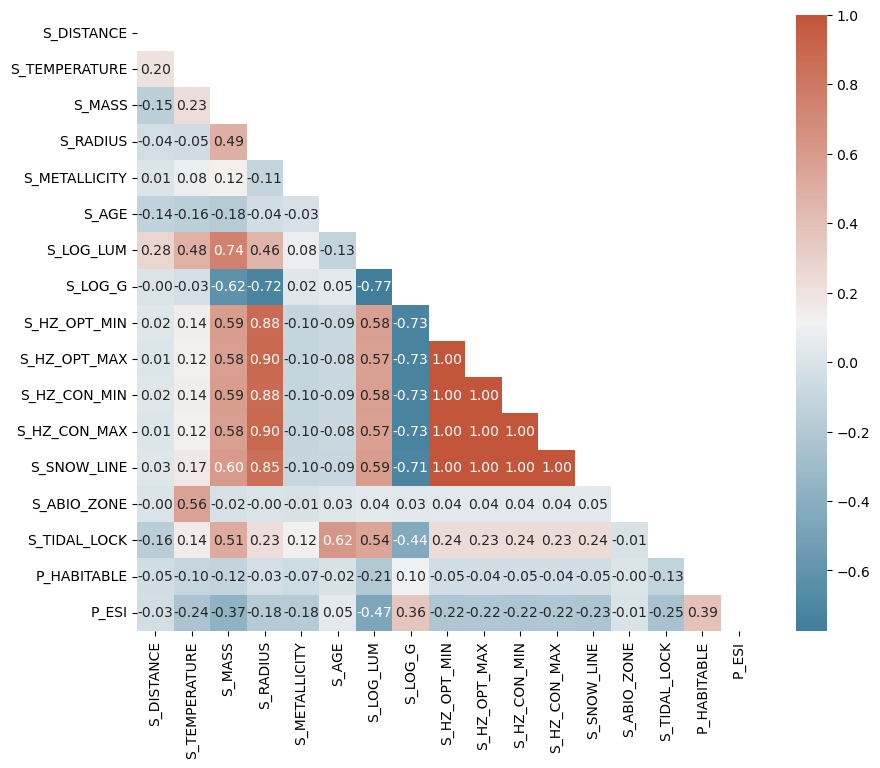

In [37]:
corrs=data[cols].corr()
import seaborn as sns
f,a = plt.subplots(figsize=(10,8))
mask = np.triu(np.ones_like(corrs,dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corrs, mask=mask, ax=a, annot=True, fmt=".2f",cmap=cmap)
plt.show()

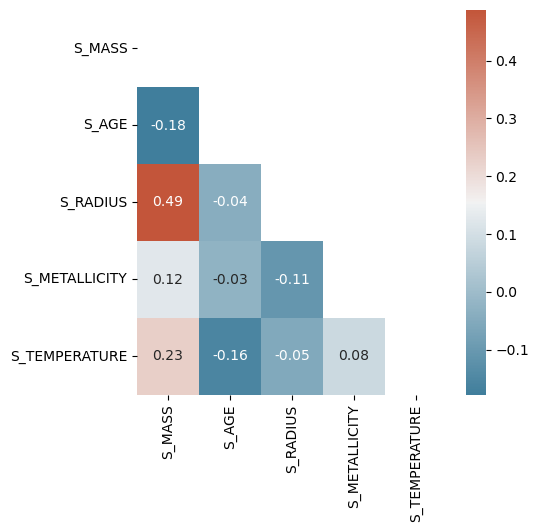

In [35]:
corrs2=data[params].corr()
f,a = plt.subplots(figsize=(5,5))
mask2 = np.triu(np.ones_like(corrs2,dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corrs2, mask=mask2, ax=a, annot=True, fmt=".2f",cmap=cmap)
plt.show()

In [5]:
data_habitable=data[data["P_HABITABLE"]>=1] # filtramos por aquellos exoplanetas considerados "habitables"

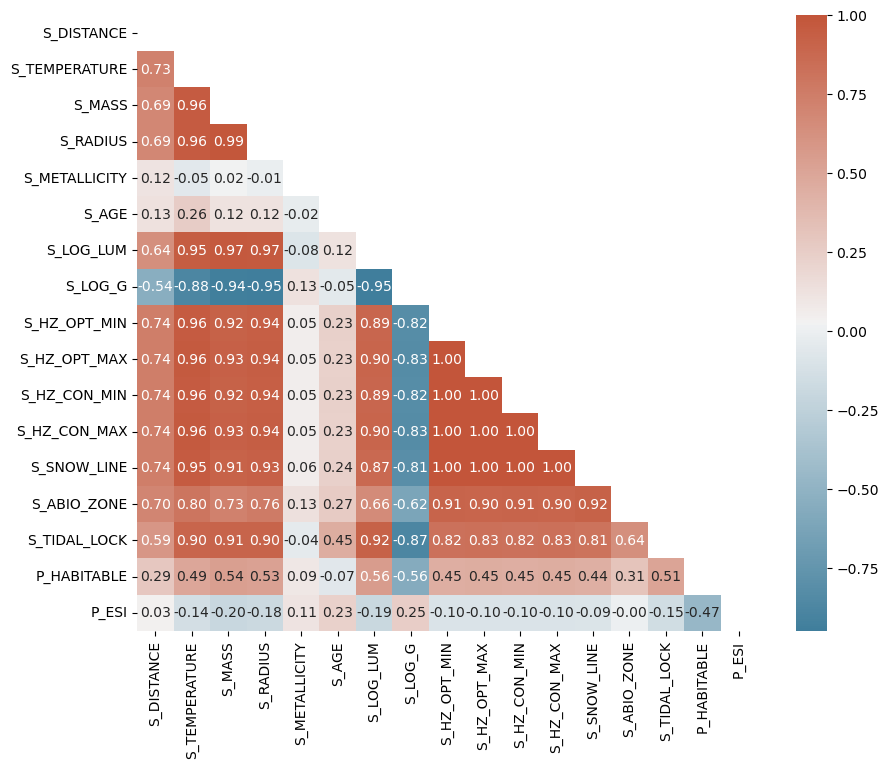

In [38]:
corrs_hab=data_habitable[cols].corr()
fi,aa = plt.subplots(figsize=(10,8))
mask = np.triu(np.ones_like(corrs_hab,dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corrs_hab, mask=mask, ax=aa, annot=True, fmt=".2f",cmap=cmap)
plt.show()

### Distancia a la mediana

In [6]:
median=[]
for item in cols:
    median.append(data_habitable[item].median()) # calculamos la mediana de los datos numéricos
criteria=dict(zip(cols,median)) # se guardan en un diccionario con la llave el nombre de columna


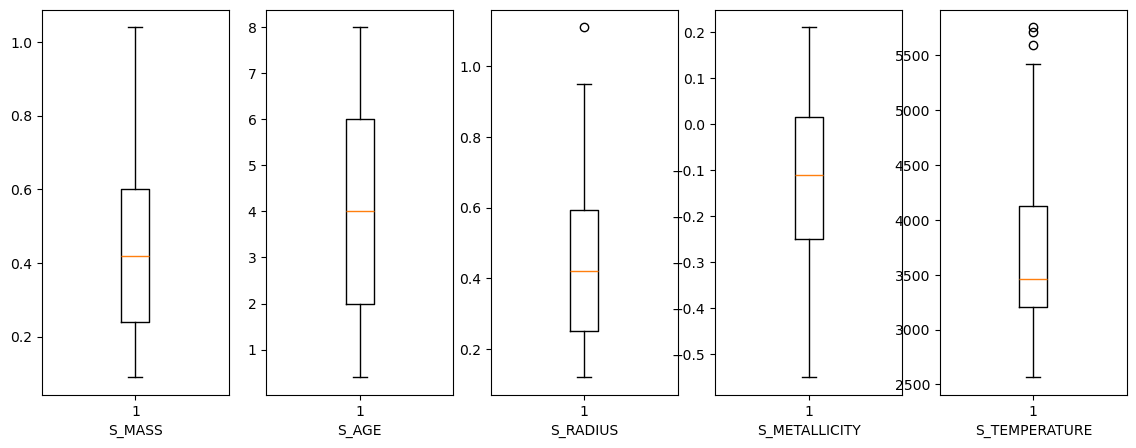

In [7]:
fig, axs =plt.subplots(1,5,figsize=(14,5)) # gráfico medio feo de estadística de nuestros parámetros más importantes
for item, i in zip(params,range(5)):
    axs[i].boxplot(data_habitable[item].dropna()) # sin NaN o queda en blanco
    axs[i].set(xlabel=item)
#fig.savefig("box.png", dpi=300) # descomentar para guardar la figura

In [8]:
near =np.ones(shape=(5,len(data_habitable))) # creamos un array para guardar las distancias a la mediana
for item, i in zip(params,range(5)):
     near[i,:]= np.abs(data_habitable[item]-criteria[item])
mean_dist=np.nanmean(near,axis=0) # promedio sin NaN, por objeto
arg=mean_dist.argsort() # ordenamos de más cercano a más lejano

In [9]:
candidates=data_habitable["P_NAME"].iloc[arg[0:3]] # nombres de los top 3 candidatos

In [10]:
selected=data_habitable.iloc[arg[0:3]] # tabla
selected

,P_NAME,S_TYPE,S_DISTANCE,S_TEMPERATURE,S_MASS,S_RADIUS,S_METALLICITY,S_AGE,S_LOG_LUM,S_LOG_G,S_TYPE_TEMP,S_HZ_OPT_MIN,S_HZ_OPT_MAX,S_HZ_CON_MIN,S_HZ_CON_MAX,S_SNOW_LINE,S_ABIO_ZONE,S_TIDAL_LOCK,P_HABITABLE,P_ESI
626,GJ 3293 d,M2.5,20.19030,3466.0,0.42,0.40,0.02,NaN,-1.658,4.78,M,0.121306,0.315318,0.153651,0.298944,0.400280,0.028616,0.345489,2,0.629777
664,GJ 433 d,M2V,9.06456,3461.0,0.48,0.47,-0.17,NaN,-1.475,4.76,M,0.149764,0.389387,0.189698,0.369166,0.494156,0.029663,0.361214,2,0.742460
480,TOI-700 e,M2.5 V,31.12650,3459.0,0.42,0.42,-0.07,1.5,-1.640,4.81,M,0.123856,0.322058,0.156882,0.305334,0.408662,0.028274,0.286631,1,0.912032


In [11]:
# definimos un diccionario con estilos de gráfico para cada seleccionado, usando colores aptos para daltónicos
estilo = dict(zip(selected["P_NAME"],[("#d81b60","dashed"),("#1e88e5","dotted"),("#004d40","dashdot")]))

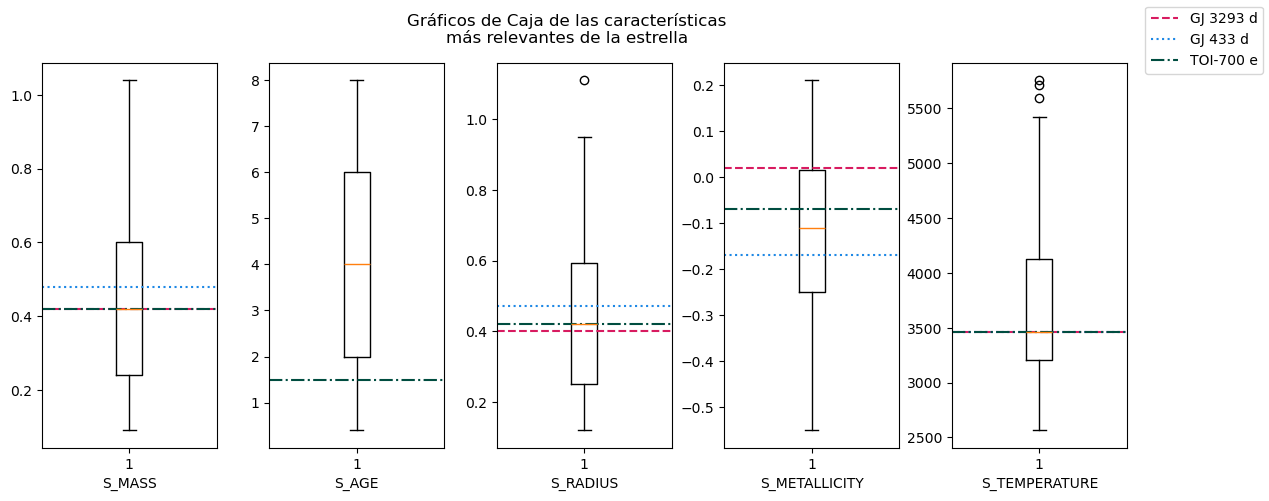

In [12]:
fig2, axs2 =plt.subplots(1,5,figsize=(14,5)) # gráfico de estadística de nuestros parámetros más importantes
for item, i in zip(params,range(5)): # iteramos en las características
    axs2[i].boxplot(data_habitable[item].dropna()) # sin NaN o queda en blanco
    for key,v in zip(estilo.keys(),range(3)): # iteramos en cada planeta
        if item == "S_MASS": # esto es para no tener 15 labels
            axs2[i].axhline(selected[item].iloc[v], ls=estilo[key][1], label=selected["P_NAME"].iloc[v], color=estilo[key][0])
        else:
            axs2[i].axhline(selected[item].iloc[v], ls=estilo[key][1], color=estilo[key][0])
    axs2[i].set(xlabel=item)
fig2.legend()
fig2.subplots_adjust(wspace=0.3) # añadimos espaciado entre los subplots para que se vea mejor
fig2.suptitle("Gráficos de Caja de las características\nmás relevantes de la estrella") # título
plt.show()
#fig.savefig("box.png", dpi=300) # descomentar para guardar la figura

In [13]:
s_type = data_habitable["S_TYPE"].dropna().apply(lambda a: a[0]) # limpieza básica de los strings para categorizar por tipo espectral

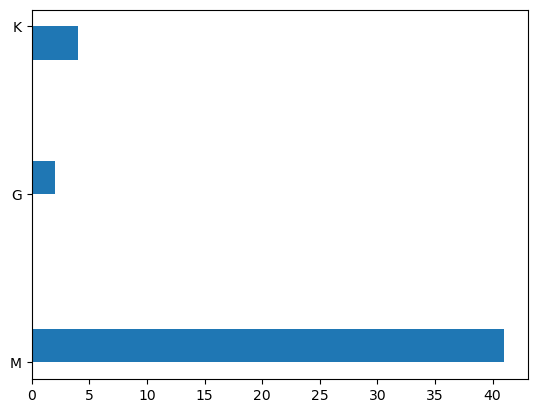

In [14]:
fig1 = plt.figure()
ax1 = fig1.add_subplot()
ax1.hist(s_type, orientation="horizontal",histtype="bar")
plt.show()

## Resultados

## Conclusiones